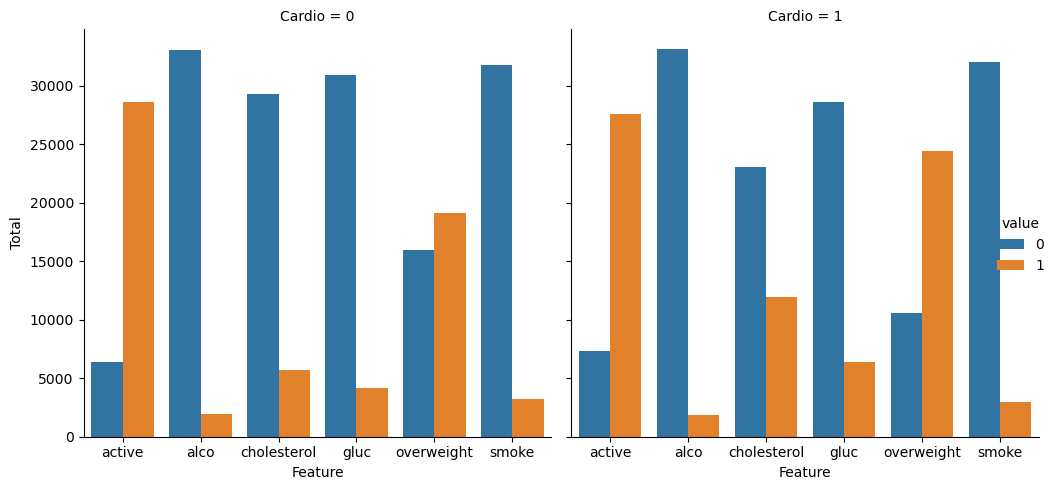

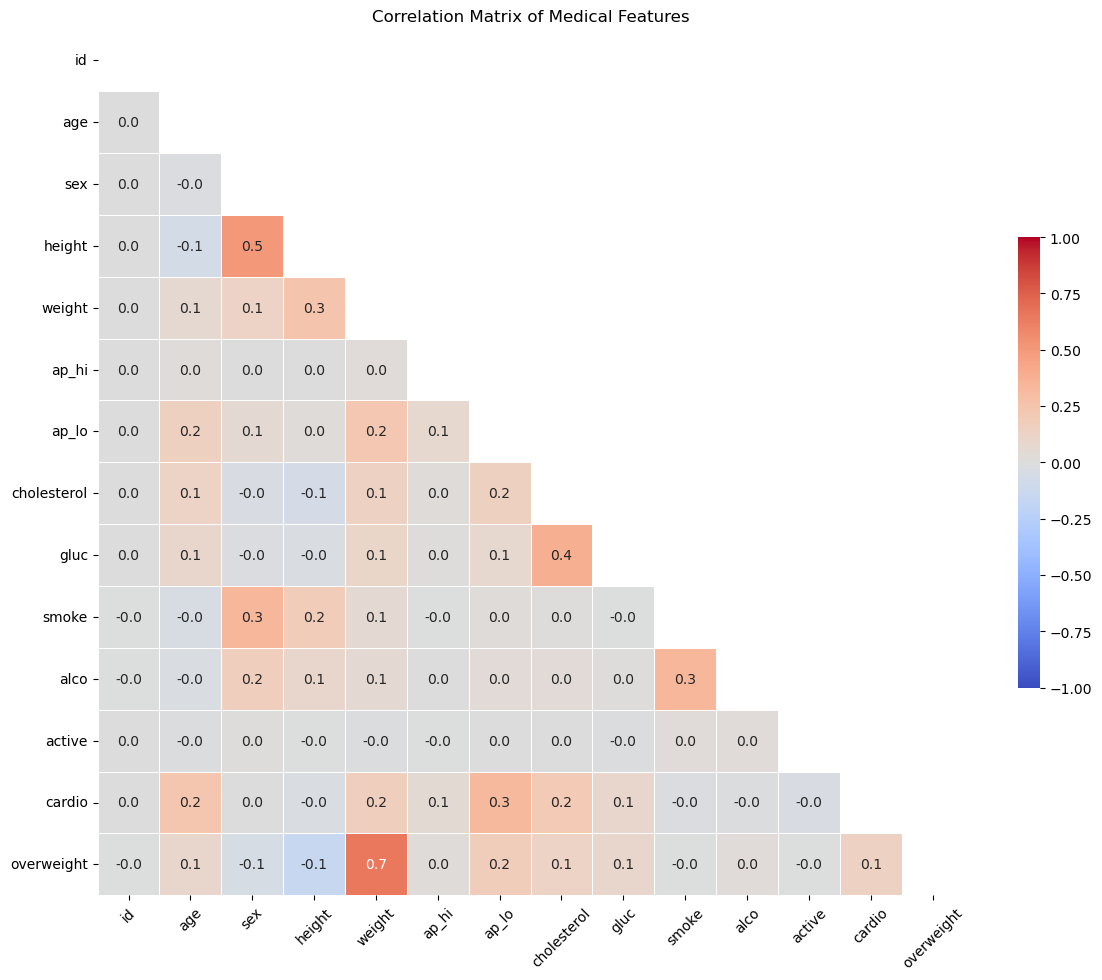

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/FreeCodeCamp/boilerplate-medical-data-visualizer/main/medical_examination.csv")

# Task 1: Add 'overweight' column
df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)
df['overweight'] = (df['BMI'] > 25).astype(int)
df.drop(columns='BMI', inplace=True)

# Task 2: Normalize 'cholesterol' and 'gluc'
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)

# Task 3: Categorical plot
df_cat = pd.melt(df, 
                 id_vars=['cardio'], 
                 value_vars=['active', 'alco', 'cholesterol', 'gluc', 'overweight', 'smoke'])

catplot = sns.catplot(data=df_cat, kind='count', x='variable', hue='value', col='cardio')
catplot.set_axis_labels("Feature", "Total")
catplot.set_titles("Cardio = {col_name}")
plt.tight_layout()
plt.show()

# Task 4: Data cleaning
df_clean = df[
    (df['ap_lo'] <= df['ap_hi']) &
    (df['height'] >= df['height'].quantile(0.025)) &
    (df['height'] <= df['height'].quantile(0.975)) &
    (df['weight'] >= df['weight'].quantile(0.025)) &
    (df['weight'] <= df['weight'].quantile(0.975))
]

# Task 5: Correlation matrix
corr = df_clean.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, 
            annot=True, 
            fmt=".1f", 
            mask=mask, 
            cmap='coolwarm', 
            center=0, 
            vmin=-1, vmax=1,
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.5})
plt.title("Correlation Matrix of Medical Features")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
